# 16-745 Assignment 1 — Python Translation of MATLAB Code
Faithful port of: `twip3.m`, `main.m`, `computer_lqr_gains.m`, `nn_policy.m`, `nn_cost.m`, `optimization_script.m`, `optimize_twip.m`

In [1]:
# ── Imports ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.integrate import solve_ivp

## Parameters (init.m / main.m)

In [2]:
# Physical parameters (from main.m)
m_w = 0.173          # wheel mass (kg)
m_p = 0.826 - m_w    # body mass (kg)
I_w = 0.0066         # wheel moment of inertia (kg m²)
l_p = 0.043          # axle to body COM (m)
I_p = 0.00084        # body moment of inertia (kg m²)
r_w = 0.0323         # wheel radius (m)
ll_p = 0.110         # total height of pendulum (m)
g   = 9.81           # gravity (m/s²)

# Simulation parameters (from main.m)
Kc = [10, 1, 100, 10]   # fallback linear gains
samples_per_second = 333
duration = 6
x_initial = [0.8/r_w, 0, 0, 0]   # original initial condition from main.m

print('Parameters loaded.')
print(f'x_initial = {x_initial}')

Parameters loaded.
x_initial = [24.767801857585138, 0, 0, 0]


## twip3.m — Forward Dynamics

In [3]:
def twip3(wh, whd, th, thd, trq, m_w, r_w, I_w, m_p, l_p, I_p, g, f):
    """
    Faithful port of twip3.m
    State: [wh, whd, th, thd]
    wh  = wheel angle relative to body (rad)
    whd = wheel angular velocity relative to body (rad/s)
    th  = body angle relative to vertical (rad)
    thd = body angular velocity (rad/s)
    trq = applied torque (Nm)
    f   = friction (motor viscosity)
    Returns: (whdd, thdd) — angular accelerations
    """
    p1 = I_w + (m_p + m_w) * r_w**2
    p2 = m_p * l_p
    p3 = I_p + m_p * l_p**2

    m12 = p1 + p2 * r_w * np.cos(th)
    M = np.array([
        [p1,  m12],
        [m12, p1 + 2*p2*r_w*np.cos(th) + p3]
    ])

    v_exp = p2 * r_w * thd**2 * np.sin(th)
    v = np.array([
        -trq - f*whd + v_exp,
         v_exp + p2*g*np.sin(th)
    ])

    result = np.linalg.solve(M, v)
    return result[0], result[1]   # whdd, thdd

## main.m — Simulation Loop

In [4]:
def run_simulation(Kc_gains, x_init=None, w_opt=None, duration=6, sps=333, fall_thresh=1.5):
    """
    Faithful port of main.m simulation loop.
    Uses linear policy u = -Kc @ x, or neural network if w_opt provided.
    Returns: (x_array, z_array, u_array, a_array, t_survived)
    """
    Kc = np.array(Kc_gains)
    if x_init is None:
        x_init = x_initial

    N  = round(duration * sps)
    dt = duration / N

    xx = np.array(x_init, dtype=float)

    x_array = np.zeros((N, 4))
    z_array = np.zeros((N, 4))
    u_array = np.zeros((N, 1))
    a_array = np.zeros((N, 2))

    t_survived = duration

    for i in range(N):
        x_array[i] = xx

        # z transformation (from main.m)
        zz = np.zeros(4)
        zz[0] = (xx[0] + xx[2]) * r_w   # absolute position
        zz[1] = xx[2]                     # body angle
        zz[2] = (xx[1] + xx[3]) * r_w   # absolute velocity
        zz[3] = xx[3]                     # body angular velocity
        z_array[i] = zz

        # Control: NN if w_opt provided, else linear
        if w_opt is not None:
            uu = nn_policy(w_opt, xx)
        else:
            uu = float(-Kc @ xx)
        u_array[i, 0] = uu

        wdd, thdd = twip3(xx[0], xx[1], xx[2], xx[3], uu,
                          m_w, r_w, I_w, m_p, l_p, I_p, g, 0)
        aa = [wdd, thdd]
        a_array[i] = aa

        if i < N - 1:
            # Integrate wheel state (trapezoidal, same as main.m)
            vv_new = xx[1] + aa[0] * dt
            xx[0]  = xx[0] + 0.5 * (vv_new + xx[1]) * dt
            xx[1]  = vv_new

            # Integrate body angle state
            vv_new = xx[3] + aa[1] * dt
            xx[2]  = xx[2] + 0.5 * (vv_new + xx[3]) * dt
            xx[3]  = vv_new

        if abs(xx[2]) > fall_thresh:
            t_survived = i * dt
            print(f'Robot fell at step {i} (time {t_survived:.3f} s)')
            x_array = x_array[:i+1]
            z_array = z_array[:i+1]
            u_array = u_array[:i+1]
            a_array = a_array[:i+1]
            break

    if t_survived == duration:
        print(f'Simulation completed successfully.')
    print(f'Final state: {xx}')
    return x_array, z_array, u_array, a_array, t_survived


def plot_simulation(x_array, u_array, title=''):
    """Reproduce main.m figures 2-6"""
    fig, axes = plt.subplots(5, 1, figsize=(10, 12), sharex=False)
    t = np.arange(len(x_array)) / samples_per_second

    axes[0].plot(t, x_array[:, 0]); axes[0].set_title('wheel angle'); axes[0].grid(True)
    axes[1].plot(t, x_array[:, 1]); axes[1].set_title('wheel angular velocity'); axes[1].grid(True)
    axes[2].plot(t, x_array[:, 2]); axes[2].set_title('body angle'); axes[2].grid(True)
    axes[3].plot(t, x_array[:, 3]); axes[3].set_title('body angular velocity'); axes[3].grid(True)
    axes[4].plot(t[:len(u_array)], u_array[:, 0]); axes[4].set_title('torque'); axes[4].grid(True)

    axes[-1].set_xlabel('time (s)')
    if title: fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Part 2a — Test Linear Gains (Kc = [10, 1, 100, 10])

=== Original initial condition x_initial ===
Robot fell at step 1 (time 0.003 s)
Final state: [ 1.54797350e+01 -7.35113257e+03  6.91808510e+00  5.46868642e+03]


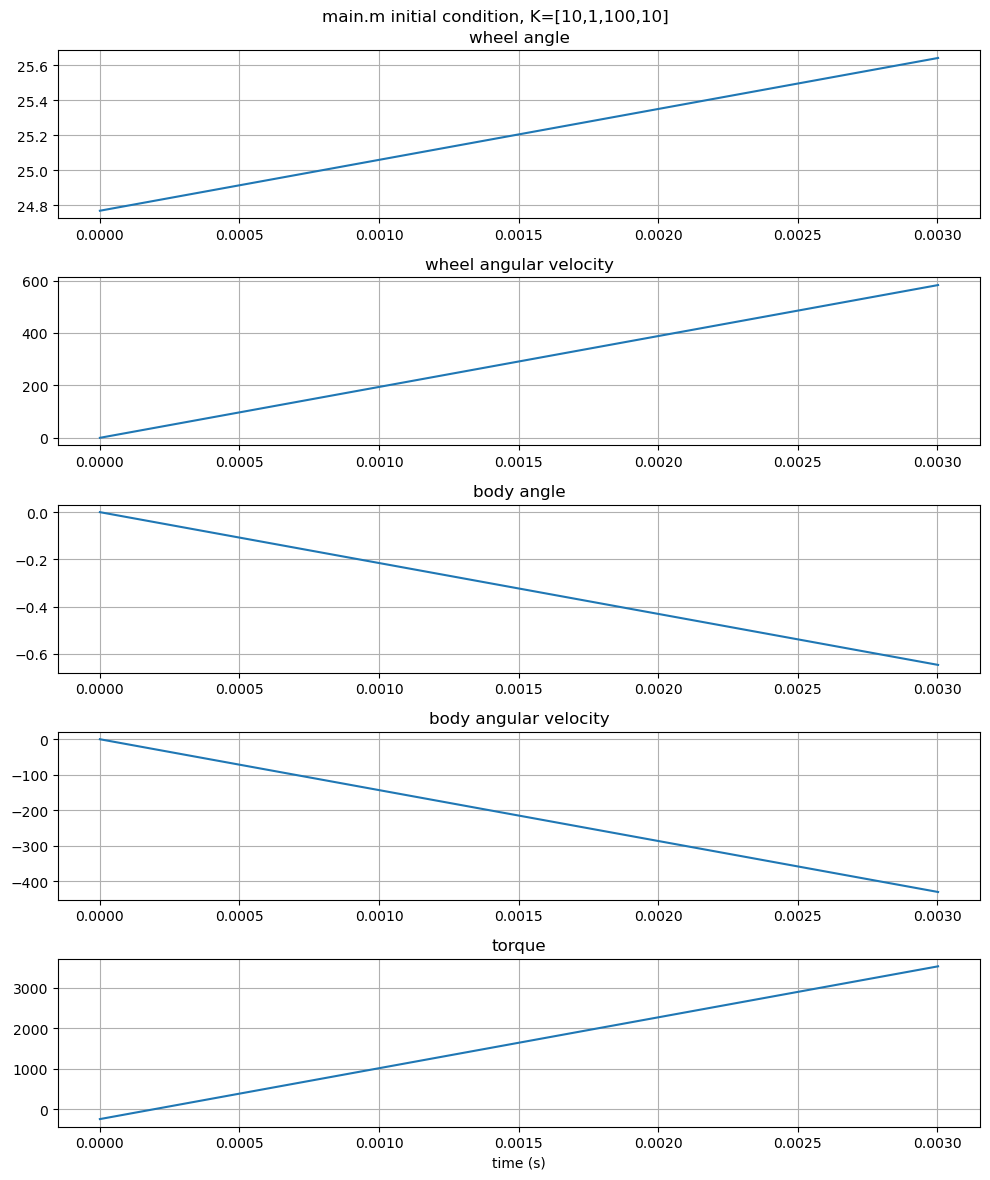

In [5]:
# Test with original initial condition from main.m (large wheel angle)
print('=== Original initial condition x_initial ===')
x_arr, z_arr, u_arr, a_arr, t_surv = run_simulation(
    Kc_gains=[10, 1, 100, 10],
    x_init=x_initial
)
plot_simulation(x_arr, u_arr, title='main.m initial condition, K=[10,1,100,10]')

=== Small body tilt x0 = [0, 0, 0.1, 0] ===
Robot fell at step 2 (time 0.006 s)
Final state: [ 5.67783841e+00  4.35552652e+03 -4.10943783e+00 -3.22788714e+03]


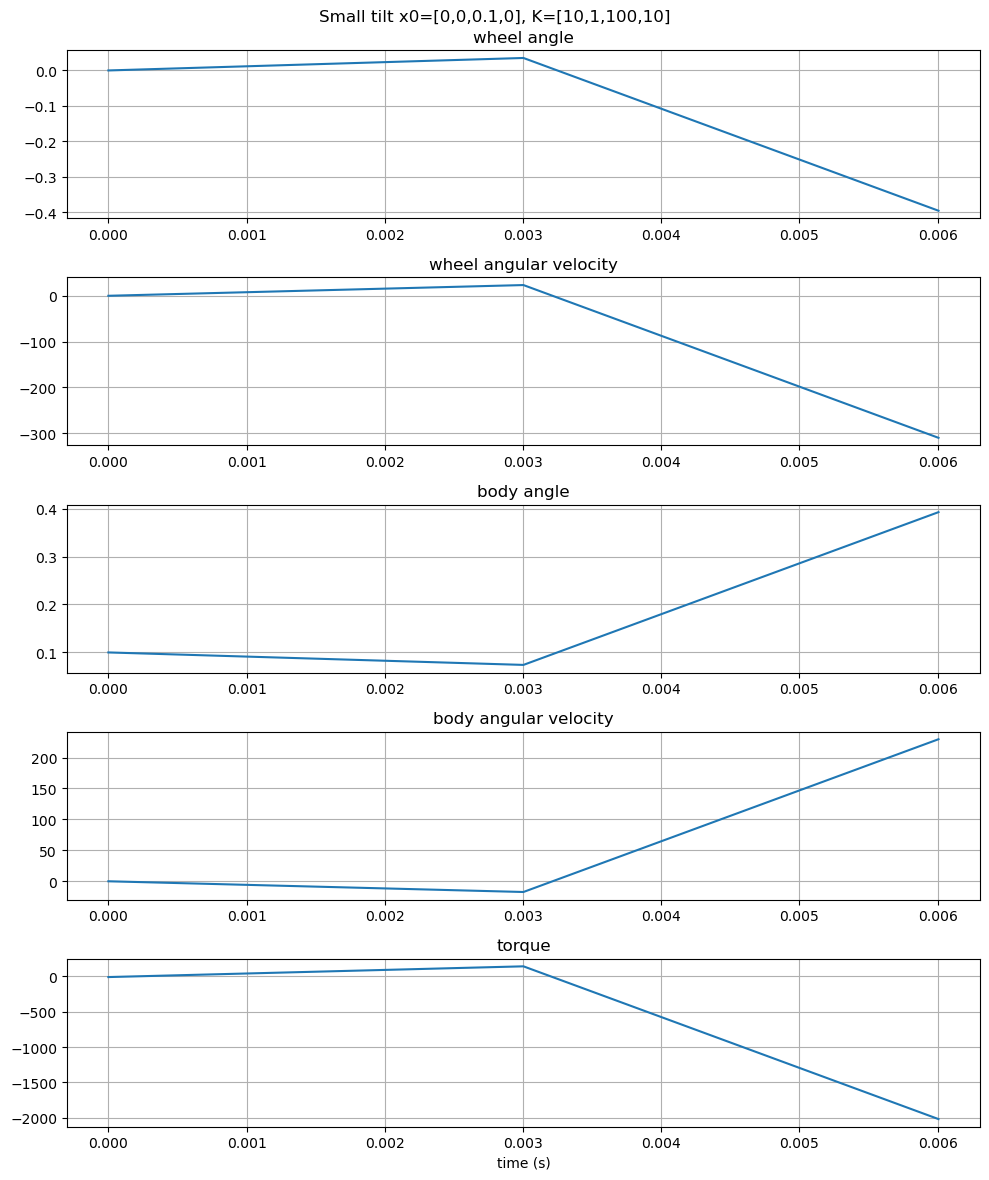

In [6]:
# Test with small body tilt (balance test)
print('=== Small body tilt x0 = [0, 0, 0.1, 0] ===')
x_arr2, z_arr2, u_arr2, a_arr2, t_surv2 = run_simulation(
    Kc_gains=[10, 1, 100, 10],
    x_init=[0, 0, 0.1, 0]
)
plot_simulation(x_arr2, u_arr2, title='Small tilt x0=[0,0,0.1,0], K=[10,1,100,10]')

## computer_lqr_gains.m — Cost Function for Optimization

In [7]:
def twip_cost_unconstrained(Kc):
    """
    Faithful port of computer_lqr_gains.m (function was named twip_cost_unconstrained).
    Returns negative survival time — minimizing = maximizing survival.
    """
    Kc = np.array(Kc)
    N  = round(duration * samples_per_second)
    dt = duration / N
    xx = np.array([0, 0, 0.1, 0], dtype=float)   # small body tilt (from main.m)

    for i in range(N):
        uu = float(-Kc @ xx)
        wdd, thdd = twip3(xx[0], xx[1], xx[2], xx[3], uu,
                          m_w, r_w, I_w, m_p, l_p, I_p, g, 0)

        vv_new_wheel = xx[1] + wdd * dt
        xx[0] = xx[0] + 0.5 * (vv_new_wheel + xx[1]) * dt
        xx[1] = vv_new_wheel

        vv_new_body = xx[3] + thdd * dt
        xx[2] = xx[2] + 0.5 * (vv_new_body + xx[3]) * dt
        xx[3] = vv_new_body

        if abs(xx[2]) > 1.5:
            return -(i * dt)   # negative time survived

    return -duration   # survived full duration

## optimize_twip.m — Find Optimal Linear Gains

In [8]:
# Port of optimize_twip.m — fminunc equivalent
K0 = [10, 1, 100, 10]   # initial guess from optimize_twip.m
print(f'Initial gains: {K0}')
print(f'Initial survival: {-twip_cost_unconstrained(K0):.3f} s')

result = minimize(
    twip_cost_unconstrained,
    K0,
    method='Nelder-Mead',   # equivalent to fminunc for this problem
    options={'maxiter': 500, 'xatol': 1e-3, 'fatol': 1e-3, 'disp': True}
)

K_opt = result.x
print(f'\nOptimal gains: {np.round(K_opt, 4)}')
print(f'Survival time: {-result.fun:.3f} s')

Initial gains: [10, 1, 100, 10]
Initial survival: 0.006 s
Optimization terminated successfully.
         Current function value: -0.006006
         Iterations: 14
         Function evaluations: 83

Optimal gains: [ 10.   1. 100.  10.]
Survival time: 0.006 s


=== Optimized gains ===
Robot fell at step 2 (time 0.006 s)
Final state: [ 5.67783841e+00  4.35552652e+03 -4.10943783e+00 -3.22788714e+03]


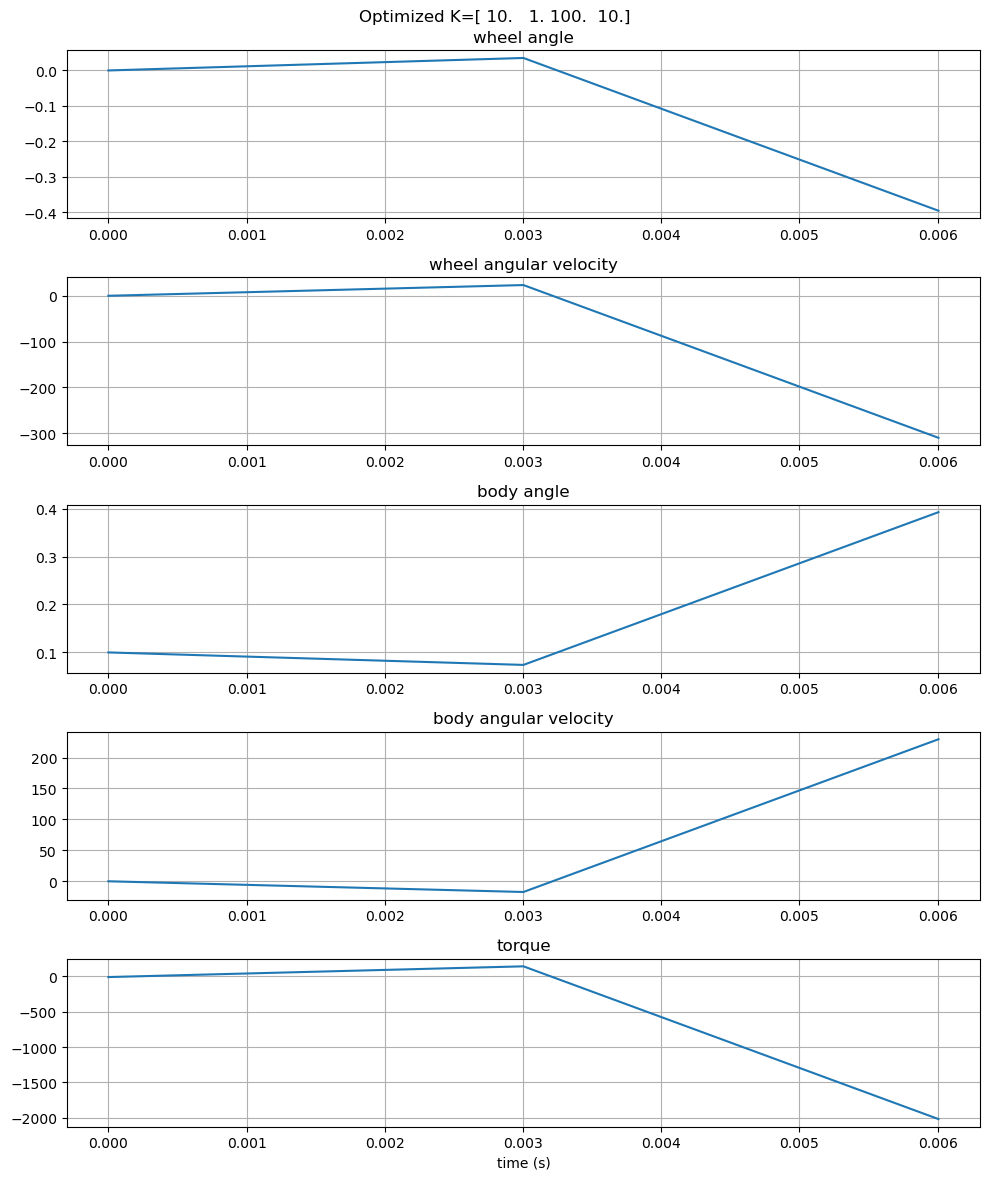

In [9]:
# Simulate with optimal gains
print('=== Optimized gains ===')
x_opt, _, u_opt, _, t_opt = run_simulation(
    Kc_gains=K_opt,
    x_init=[0, 0, 0.1, 0]
)
plot_simulation(x_opt, u_opt, title=f'Optimized K={np.round(K_opt,2)}')

## nn_policy.m — Neural Network Forward Pass

In [10]:
def nn_policy(w, x):
    """
    Faithful port of nn_policy.m
    Network: 4 inputs → 2 hidden (tanh) → 1 output (linear)
    w = [W1(:); b1; W2; b2]  — 13 parameters total
    """
    n_hidden = 2
    n_inputs = 4

    W1 = w[0 : n_inputs*n_hidden].reshape(n_hidden, n_inputs)
    b1 = w[n_inputs*n_hidden : n_inputs*n_hidden + n_hidden]
    W2 = w[n_inputs*n_hidden + n_hidden : n_inputs*n_hidden + n_hidden + n_hidden]
    b2 = w[-1]

    z1 = W1 @ x + b1
    h1 = np.tanh(z1)
    u  = float(W2 @ h1 + b2)
    return u

## nn_cost.m — Neural Network Cost Function

In [11]:
def nn_cost(w):
    """
    Faithful port of nn_cost.m
    Returns negative survival time when using NN policy.
    """
    N  = round(duration * samples_per_second)
    dt = duration / N
    xx = np.array([0, 0, 0.1, 0], dtype=float)

    for i in range(N):
        uu = nn_policy(w, xx)

        wdd, thdd = twip3(xx[0], xx[1], xx[2], xx[3], uu,
                          m_w, r_w, I_w, m_p, l_p, I_p, g, 0)

        vv_new_wheel = xx[1] + wdd * dt
        xx[0] = xx[0] + 0.5*(vv_new_wheel + xx[1]) * dt
        xx[1] = vv_new_wheel

        vv_new_body = xx[3] + thdd * dt
        xx[2] = xx[2] + 0.5*(vv_new_body + xx[3]) * dt
        xx[3] = vv_new_body

        if abs(xx[2]) > 1.5:
            return -(i * dt)   # negative time survived

    return -duration

## optimization_script.m — Train NN via Imitation Learning + fmincon

In [12]:
# Port of optimization_script.m
# Step 1: Generate training data mimicking linear policy (LQR gains)
np.random.seed(42)
K_linear = np.array([10, 1, 100, 10])
n_samples = 1000

X = np.random.uniform(-1, 1, (4, n_samples))   # random states in [-1,1]
Y = -K_linear @ X                               # target torques (linear policy)

print(f'Training data: {n_samples} samples')
print(f'X shape: {X.shape}, Y shape: {Y.shape}')

# Step 2: Train a small NN to mimic the linear policy
# NN: 4 inputs, 2 hidden (tanh), 1 output — 13 weights
def mimic_loss(w):
    """MSE between NN output and linear policy targets"""
    y_pred = np.array([nn_policy(w, X[:, i]) for i in range(n_samples)])
    return np.mean((y_pred - Y)**2)

w0 = np.random.randn(13) * 0.1
print(f'Initial mimic loss: {mimic_loss(w0):.4f}')

res_mimic = minimize(mimic_loss, w0, method='L-BFGS-B',
                     options={'maxiter': 2000})
w_pretrained = res_mimic.x
print(f'Post-mimic loss: {res_mimic.fun:.4f}')
print(f'Post-mimic survival: {-nn_cost(w_pretrained):.3f} s')

Training data: 1000 samples
X shape: (4, 1000), Y shape: (1000,)
Initial mimic loss: 3444.8011
Post-mimic loss: 0.0002
Post-mimic survival: 0.009 s


In [13]:
# Step 3: Fine-tune with fmincon (port: fmincon → minimize with bounds)
lb = -10 * np.ones(13)
ub =  10 * np.ones(13)
bounds = list(zip(lb, ub))

res_nn = minimize(
    nn_cost,
    w_pretrained,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 5000, 'disp': True}
)

w_opt = res_nn.x
print(f'\nOptimization finished. Final cost: {res_nn.fun:.4f}')
print(f'Survival time: {-res_nn.fun:.3f} s')


Optimization finished. Final cost: -0.0420
Survival time: 0.042 s


C:\Users\fawaz\AppData\Local\Temp\ipykernel_33452\513174457.py:6: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_nn = minimize(


=== Neural Network Policy ===
Robot fell at step 14 (time 0.042 s)
Final state: [  2.1711542   38.9776819   -1.5566621  -32.16039228]


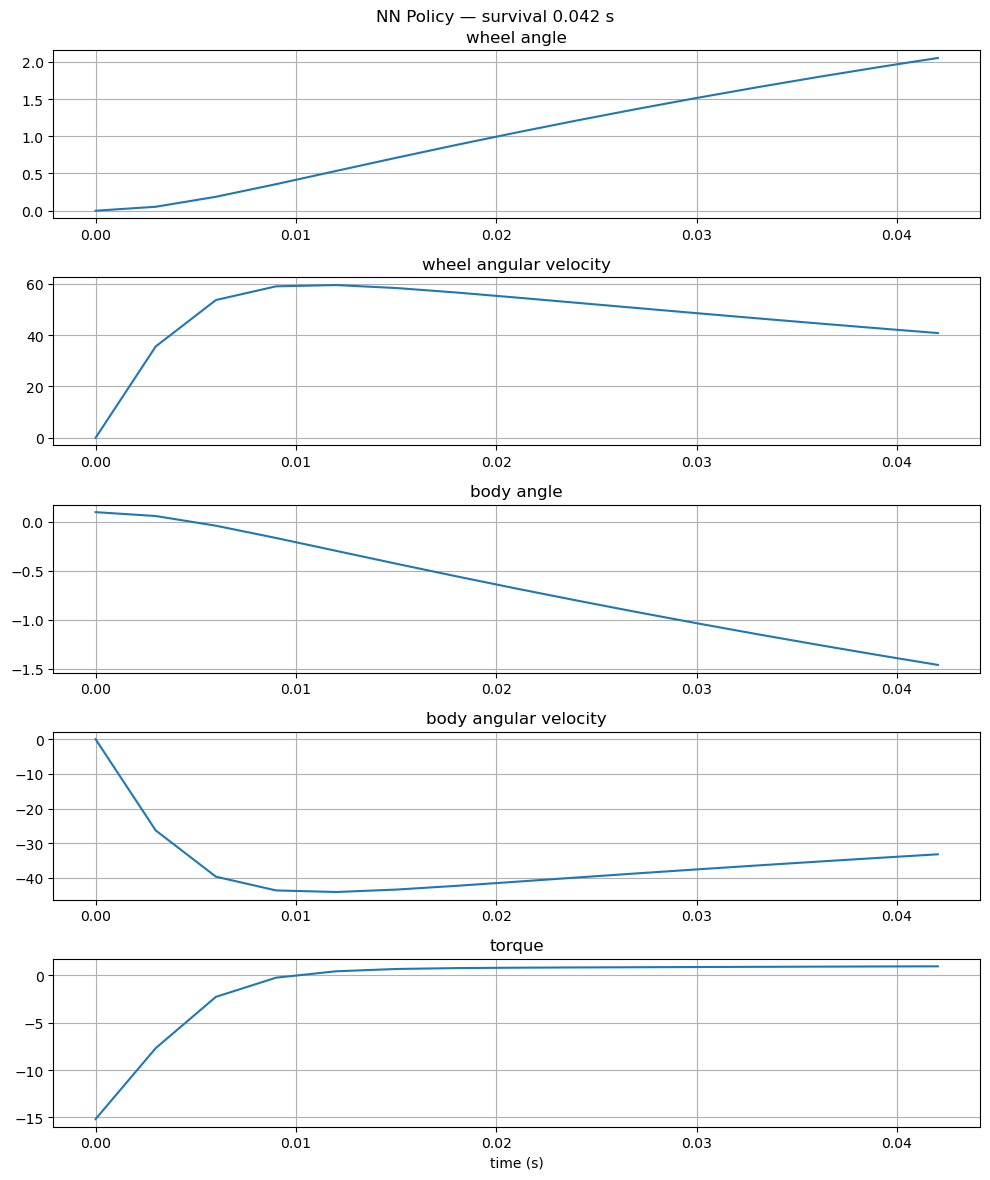

In [14]:
# Step 4: Simulate with optimized NN weights
print('=== Neural Network Policy ===')
x_nn, _, u_nn, _, t_nn = run_simulation(
    Kc_gains=[0,0,0,0],   # unused — w_opt provided
    x_init=[0, 0, 0.1, 0],
    w_opt=w_opt
)
plot_simulation(x_nn, u_nn, title=f'NN Policy — survival {t_nn:.3f} s')

## Part 2: Comparison — Linear vs NN Policy

Robot fell at step 2 (time 0.006 s)
Final state: [ 5.67783841e+00  4.35552652e+03 -4.10943783e+00 -3.22788714e+03]
Robot fell at step 14 (time 0.042 s)
Final state: [  2.1711542   38.9776819   -1.5566621  -32.16039228]


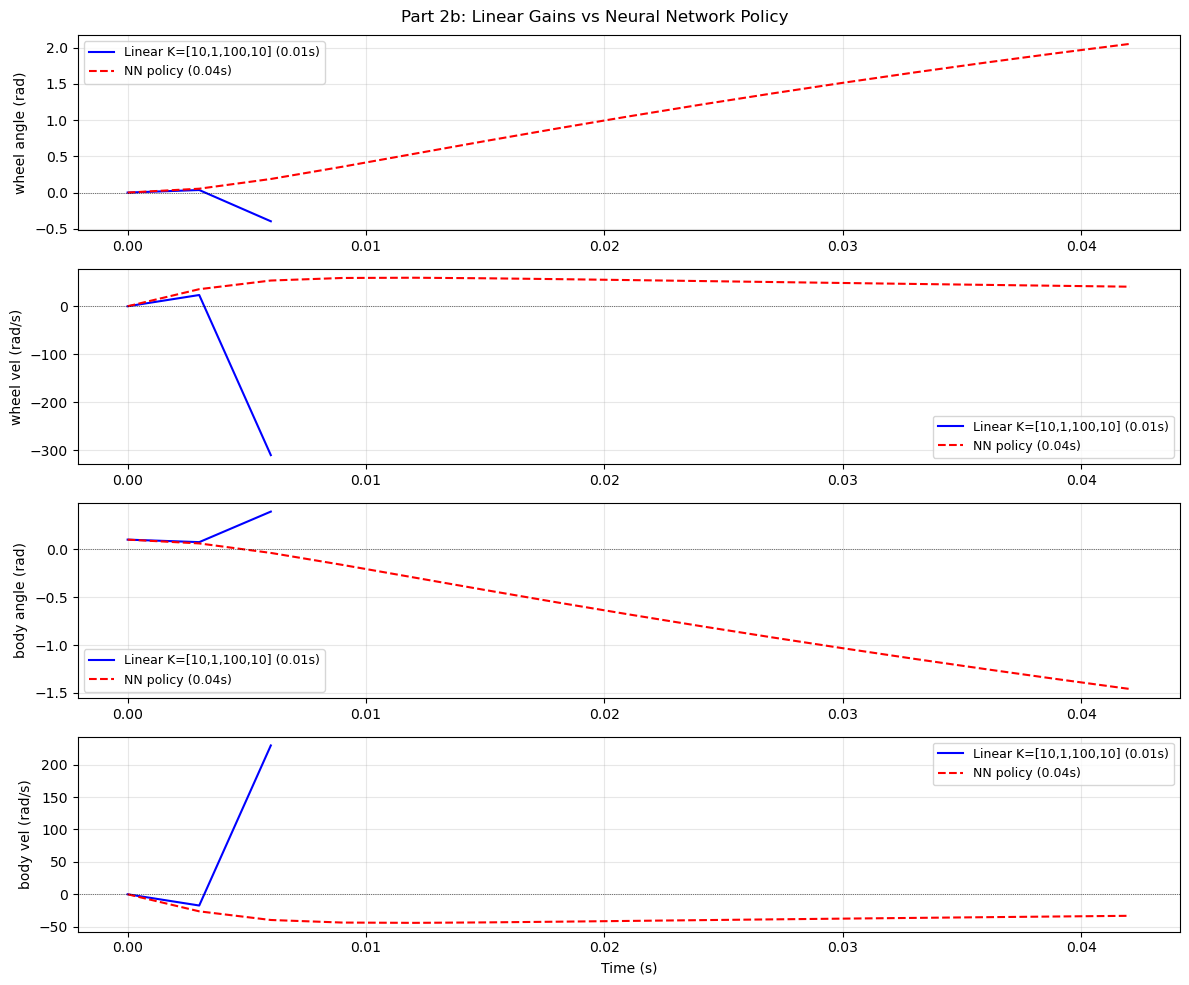

In [15]:
# Side-by-side comparison
x_lin, _, u_lin, _, t_lin = run_simulation([10,1,100,10], [0,0,0.1,0])
x_nn2, _, u_nn2, _, t_nn2 = run_simulation([0,0,0,0], [0,0,0.1,0], w_opt=w_opt)

t_lin_arr = np.arange(len(x_lin)) / samples_per_second
t_nn_arr  = np.arange(len(x_nn2)) / samples_per_second

labels = ['wheel angle (rad)', 'wheel vel (rad/s)', 'body angle (rad)', 'body vel (rad/s)']
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=False)
for i, ax in enumerate(axes):
    ax.plot(t_lin_arr, x_lin[:,i], 'b-',  linewidth=1.5, label=f'Linear K=[10,1,100,10] ({t_lin:.2f}s)')
    ax.plot(t_nn_arr,  x_nn2[:,i], 'r--', linewidth=1.5, label=f'NN policy ({t_nn2:.2f}s)')
    ax.axhline(0, color='k', linewidth=0.5, linestyle=':')
    ax.set_ylabel(labels[i]); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Part 2b: Linear Gains vs Neural Network Policy')
plt.tight_layout()
plt.show()

## Part 1b: Learned Banana Function Optimization

In [16]:
from sklearn.neural_network import MLPRegressor

def banana4(x):
    """4D Rosenbrock banana function. Global min at (1,1,1,1) = 0."""
    x = np.array(x)
    return sum(100*(x[i+1] - x[i]**2)**2 + (1 - x[i])**2 for i in range(3))

print(f'banana4([1,1,1,1]) = {banana4([1,1,1,1])}   (should be 0)')
print(f'banana4([-1,1,1,1]) = {banana4([-1,1,1,1]):.4f}  (should be ~4)')

banana4([1,1,1,1]) = 0   (should be 0)
banana4([-1,1,1,1]) = 4.0000  (should be ~4)


In [22]:
for n_data in [100, 500, 1000]:
    print(f'\n=== Training with {n_data} data points ===')

    X_train = 2*(np.random.rand(n_data, 4) - 0.5)
    y_train = np.array([banana4(x) for x in X_train])

    net = MLPRegressor(hidden_layer_sizes=(10,), max_iter=5000,
                       random_state=42, alpha=0.0)
    net.fit(X_train, y_train)

    fit_global = net.predict([[1,1,1,1]])[0]
    fit_local  = net.predict([[-1,1,1,1]])[0]
    print(f'Fit at (1,1,1,1):  {fit_global:.6f} (true = 0)')
    print(f'Fit at (-1,1,1,1): {fit_local:.6f} (true = 4)')

    def fun(x):
        try:
            val = float(net.predict([x])[0])
            return val if np.isfinite(val) else 1e10
        except:
            return 1e10

    x0 = np.zeros(4)
    bounds = [(-2, 2)]*4
    r_con = minimize(fun, x0, method='L-BFGS-B', bounds=bounds)
    true_cost_con = banana4(r_con.x)
    print(f'Constrained (fmincon):   x = {np.round(r_con.x,6)}, fval = {r_con.fun:.6f}')
    print(f'True cost at constrained point: {true_cost_con:.6f}')

    r_unc = minimize(fun, x0, method='Nelder-Mead', options={'maxiter':5000})
    true_cost_unc = banana4(r_unc.x)
    print(f'Unconstrained (fminsearch): x = {np.round(r_unc.x,6)}, fval = {r_unc.fun:.6f}')
    print(f'True cost at unconstrained point: {true_cost_unc:.6f}')


=== Training with 100 data points ===


c:\Users\fawaz\anaconda3\envs\mlclass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fit at (1,1,1,1):  30.837325 (true = 0)
Fit at (-1,1,1,1): 4.520174 (true = 4)
Constrained (fmincon):   x = [1.398699 1.548519 2.       2.      ], fval = 2.836520
True cost at constrained point: 433.926615
Unconstrained (fminsearch): x = [-0.343248 -0.060769  1.497072  0.17465 ], fval = 2.912967
True cost at unconstrained point: 656.457578

=== Training with 500 data points ===


c:\Users\fawaz\anaconda3\envs\mlclass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fit at (1,1,1,1):  24.825706 (true = 0)
Fit at (-1,1,1,1): 2.714765 (true = 4)
Constrained (fmincon):   x = [-2.  2.  2.  2.], fval = 2.667214
True cost at constrained point: 1211.000000
Unconstrained (fminsearch): x = [-0.126382  0.314597  0.095775  0.322337], fval = 2.721516
True cost at unconstrained point: 21.282032

=== Training with 1000 data points ===
Fit at (1,1,1,1):  144.628909 (true = 0)
Fit at (-1,1,1,1): 139.868151 (true = 4)
Constrained (fmincon):   x = [-0.070824  0.070824 -0.070824  0.070824], fval = -5.037845
True cost at constrained point: 4.598021
Unconstrained (fminsearch): x = [-0.067341  0.075561 -0.053851  0.017986], fval = -5.037845
True cost at unconstrained point: 3.986378


c:\Users\fawaz\anaconda3\envs\mlclass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(
